# 🚀 통합 농산물 가격 예측 하이브리드 모델링
본 노트북은 ML(LGBM)과 DL(Chronos-2 Large)을 결합하여 21개 농작물의 t+7, t+14, t+28 가격을 예측합니다.

## 1. 환경 설정 및 라이브러리 임포트

In [185]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from datetime import timedelta
import lightgbm as lgb
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import optuna
import torch
from korean_font import set_korean_font


# 구글 코랩 환경 확인 및 드라이브 마운트
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_PATH = '/content/drive/MyDrive/data/' # 사용자 경로에 맞게 수정
    # Colab 한글 폰트 설정
    !sudo apt-get -qq -y install fonts-nanum > /dev/null
    import matplotlib.font_manager as fm
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    fm.fontManager.addfont(font_path)
    plt.rc('font', family='NanumBarunGothic')
else:
    DATA_PATH = 'data/'
    plt.rc('font', family='Malgun Gothic') # Windows


set_korean_font()

plt.rcParams['axes.unicode_minus'] = False
print("환경 설정 완료.")

한글 폰트 설정: NanumGothic (/usr/share/fonts/truetype/nanum/NanumGothic.ttf)
환경 설정 완료.


#### 전처리 파일
'preprocess.py'의 코드를 주석처리하여 업로드합니다.
실제 사용시 별도의 파일로 사용.

In [186]:
# # =============================================================================
# # [설정 상수] - standardize_origin() 및 전처리 전반에서 사용됨
# # =============================================================================

# # 1. 시도 명칭 표준화 맵: '강원도' -> '강원특별자치도' 등 다양한 표기를 하나로 통일
# SIDO_CLEAN_MAP = {
#     '강원': '강원특별자치도', '강원도': '강원특별자치도', '강원특별자치도': '강원특별자치도',
#     '전북': '전북특별자치도', '전라북도': '전북특별자치도', '전북특별자치도': '전북특별자치도',
#     '제주': '제주특별자치도', '제주도': '제주특별자치도', '제주특별자치도': '제주특별자치도',
#     '세종시': '세종특별자치시', '세종특별자치시': '세종특별자치시',
#     '경북': '경상북도', '경상북도': '경상북도', '경남': '경상남도', '경상남도': '경상남도',
#     '전남': '전라남도', '전라남도': '전라남도', '충남': '충청남도', '충청남도': '충청남도',
#     '충북': '충청북도', '충청북도': '충청북도', '경기': '경기도', '경기도': '경기도',
#     '서울': '서울특별시', '서울특별시': '서울특별시', '부산': '부산광역시', '부산광역시': '부산광역시',
#     '대구': '대구광역시', '대구광역시': '대구광역시', '인천': '인천광역시', '인천광역시': '인천광역시',
#     '광주': '광주광역시', '광주광역시': '광주광역시', '대전': '대전광역시', '대전광역시': '대전광역시',
#     '울산': '울산광역시', '울산광역시': '울산광역시'
# }

# # 2. 수입 국가 리스트: 산지 정보가 국가명으로 들어온 경우를 판별
# COUNTRY_LIST = [
#     '베트남', '중국', '미국', '미얀마', '뉴질랜드', '대만', '스페인', '호주', 
#     '오스트리아', '멕시코', '필리핀', '가나', '벨기에', '일본', '네덜란드', 
#     '칠레', '태국', '페루', '마이너'
# ]

# # 3. 수입 판정 키워드: 국가명 외에 수입산임을 나타내는 키워드
# IMPORT_KEYWORDS = ['수입산', '기타국', '원양산', '태평양', '대서양']

# # 수입 판정 통합 키워드 셋 (검색 속도 최적화용)
# OVERSEAS_KEYWORDS = set(COUNTRY_LIST + IMPORT_KEYWORDS)

# # 4. 시군구 정제 제외 리스트: 시군구 컬럼에 시도 명칭이 중복 기입된 경우를 걸러내기 위함
# SIDO_NAMES = set(list(SIDO_CLEAN_MAP.keys()) + list(SIDO_CLEAN_MAP.values()))


# # =============================================================================
# # [메인 파이프라인]
# # =============================================================================

# def preprocess(df):
#     """모든 전처리 단계를 로직 순서에 따라 실행하는 메인 함수"""
#     # 0. 컬럼명 정제 (대문자 'DATE'를 소문자 'date'로 통일 및 BOM 제거)
#     df.columns = [col.strip().replace('\ufeff', '') for col in df.columns]
#     if 'DATE' in df.columns and 'date' not in df.columns:
#         df = df.rename(columns={'DATE': 'date'})
        
#     original_len = len(df)
    
#     # 1. 기본 수치 데이터 정제
#     df = clean_numeric_columns(df)
#     df = filter_invalid_rows(df)
    
#     # 2. 산지 정보 정제
#     df = standardize_origin(df)
    
#     # 3. 시간 데이터 파생 변수 생성
#     _preprocess_date(df)
    
#     # 4. 핵심 컬럼 정리 및 재정렬
#     df = select_essential_columns(df)
    
#     # 5. 인적 오류(Human Error) 제거 (개별 거래 단위 정제)
#     df = remove_human_errors(df)
    
#     # 6. 품목 및 날짜별 일별 집계 (최종 결과물 형태)
#     df = aggregate_daily_data(df)
    
#     # 7. 인덱스 재정렬 및 최종 리포트 출력
#     df = df.reset_index(drop=True)
#     final_len = len(df)
#     print(f"--- [전처리 완료] 초기 데이터: {original_len:,}행 -> 최종 일별 집계: {final_len:,}행 ---")
    
#     return df


# # =============================================================================
# # [1단계: 수치 및 유효성 전처리]
# # =============================================================================

# def clean_numeric_columns(df):
#     """수치형 컬럼(총거래금액, 총거래물량, 평균가격)의 콤마 제거 및 숫자 변환"""
#     target_cols = ['총거래금액', '총거래물량', '평균가격']
#     for col in target_cols:
#         if col in df.columns:
#             if df[col].dtype == 'object':
#             # dtype이 object(문자열 포함)인 경우에만 콤마 제거 로직 실행 (regex=False로 속도 향상)
#                 df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '', regex=False), errors='coerce')
#             else:
#             # 이미 숫자형이라면 단순 변환
#                 df[col] = pd.to_numeric(df[col], errors='coerce')
#     return df

# def filter_invalid_rows(df):
#     """유효한 데이터(0보다 큰 값)만 필터링"""
#     initial_count = len(df)
#     # 총거래물량은 1kg 이상이어야 함
#     valid_mask = (
#         (df['총거래금액'] > 0) & 
#         (df['총거래물량'] >= 1) & 
#         (df['평균가격'] > 0)
#     )
#     df = df[valid_mask].copy()
    
#     final_count = len(df)
#     dropped_count = initial_count - final_count
    
#     print(f"작업 전 데이터 수: {initial_count:,} 행")
#     print(f"삭제된 데이터 수: {dropped_count:,} 행")
#     print(f"최종 정제 데이터 수: {final_count:,} 행")
#     print(f"데이터 유지율: {(final_count / initial_count) * 100:.2f}%" if initial_count > 0 else "데이터 없음")
    
#     return df


# # =============================================================================
# # [2단계: 산지 및 지역 정보 정제]
# # =============================================================================

# def standardize_origin(df):
#     """산지 정보를 정제하는 통합 모듈"""
#     df = _classify_origin_type(df)
#     df = _clean_sigungu_names(df)
#     df = _format_final_origin(df)
#     return df

# def _classify_origin_type(df):
#     """국산/수입 여부 및 기본 광역시도 분류"""
#     df['광역시도'] = '기타/미상'
#     df['국산여부'] = '기타/미상'

#     # 판별 마스크
#     is_domestic = df['산지-광역시도'].isin(SIDO_CLEAN_MAP.keys())
#     is_overseas_direct = df['산지-광역시도'].isin(OVERSEAS_KEYWORDS)
#     is_overseas_hyphen = (df['산지-광역시도'] == '-') & (df['품종'].str.contains(r'\(수입\)', na=False, regex=True))
#     is_overseas = is_overseas_direct | is_overseas_hyphen

#     # 국산 데이터 매핑
#     df.loc[is_domestic, '광역시도'] = df['산지-광역시도'].map(SIDO_CLEAN_MAP)
#     df.loc[is_domestic, '국산여부'] = '국산'

#     # 수입 데이터 매핑
#     df.loc[is_overseas, '국산여부'] = '수입'
#     is_country_name = df['산지-광역시도'].isin(COUNTRY_LIST)
#     df.loc[is_country_name, '광역시도'] = df['산지-광역시도']
    
#     return df

# def _clean_sigungu_names(df):
#     """시군구 정보 정제 및 예외 처리"""
#     df['시군구'] = df['산지-시군구']
    
#     # 국산/수입 여부에 따른 시군구 강제 할당
#     df.loc[df['국산여부'] == '수입', '시군구'] = '수입'
#     df.loc[df['국산여부'] == '기타/미상', '시군구'] = '기타/미상'

#     # 시군구 컬럼에 광역 지명이 잘못 들어간 경우 제거
#     is_sido_in_sigungu = df['시군구'].isin(SIDO_NAMES)
#     df.loc[is_sido_in_sigungu, '시군구'] = '기타/미상'
    
#     return df

# def _format_final_origin(df):
#     """최종 통합 '산지' 컬럼 생성 (예: '경기도 안성시', '수입(미국)')"""
#     sido_etc = (df['광역시도'] == '기타/미상')
#     sigungu_etc = (df['시군구'] == '기타/미상')

#     # 케이스별 결합 조건
#     conditions = [
#         (~sido_etc) & (~sigungu_etc), # 둘 다 정보 있음 -> '시도 + 시군구'
#         (~sido_etc) & (sigungu_etc),  # 시도만 있음 -> '시도'
#         (sido_etc) & (~sigungu_etc),  # 시군구만 있음 -> '시군구'
#     ]
#     choices = [
#         df['광역시도'] + " " + df['시군구'], 
#         df['광역시도'],                      
#         df['시군구']                         
#     ]
#     df['산지'] = np.select(conditions, choices, default='기타/미상')

#     # 수입산 특수 포맷팅
#     is_import = (df['국산여부'] == '수입')
#     temp_country = df.loc[is_import, '광역시도'].replace('기타/미상', '기타')
#     df.loc[is_import, '산지'] = "수입(" + temp_country + ")"
    
#     return df


# # =============================================================================
# # [3단계: 시간 데이터 파싱]
# # =============================================================================

# def _preprocess_date(df):
#     """날짜 변환 및 파생 변수 생성 (시간 정보 제거 포함)"""
#     # 날짜 변환 및 시간 정보 제거 (normalize)
#     if not pd.api.types.is_datetime64_any_dtype(df['date']):
#         df['date'] = pd.to_datetime(df['date'], format='mixed').dt.normalize()
#     else:
#         df['date'] = df['date'].dt.normalize()

#     df['Year'] = df['date'].dt.year
#     df['Quarter'] = df['date'].dt.quarter
#     df['Month'] = df['date'].dt.month
#     df['Week'] = df['date'].dt.isocalendar().week.astype(int)
#     df['Day'] = df['date'].dt.day
#     df['DayOfWeek'] = df['date'].dt.day_name()
    
#     # 요일 순서 정렬
#     days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
#     df['DayOfWeek'] = pd.Categorical(df['DayOfWeek'], categories=days_order, ordered=True)


# # =============================================================================
# # [4단계: 핵심 컬럼 선택]
# # =============================================================================

# def select_essential_columns(df):
#     """분석에 필요한 핵심 컬럼만 유지하고 재정렬"""
#     # 1. 평균가격 새로 계산 (kg당 가격)
#     df['평균가격'] = df['총거래금액'] / df['총거래물량']
    
#     # 2. 필수 컬럼 정의 및 정렬 순서
#     # DATE (앞) + 핵심 지표 (중간) + 시계열 파생변수 (뒤)
#     essential_cols = [
#         'date', '품목', '총거래금액', '총거래물량', '평균가격', '품종', '등급', '국산여부', '산지',
#         'Year', 'Quarter', 'Month', 'Week', 'Day', 'DayOfWeek'
#     ]
    
#     # 실제 존재하는 컬럼만 선택
#     existing_cols = [col for col in essential_cols if col in df.columns]
#     return df[existing_cols].copy()


# # =============================================================================
# # [5단계: 인적 오류 제거]
# # =============================================================================

# def remove_human_errors(df):
#     """
#     평균가격(단가)을 기준으로 인적 오류(Human Error) 가능성이 높은 행 제거.
#     - 그룹핑 수준: 1차(품종+등급) -> 2차(품종) -> 3차(전체) 단계별 방어 로직 적용
#     """
#     if df.empty:
#         return df
        
#     # 결측치가 있으면 groupby 연산에서 누락될 수 있으므로 임시 채움
#     df['품종'] = df['품종'].fillna('미상')
#     df['등급'] = df['등급'].fillna('미상')
    
#     # 1차 기준: [Year, Week, 품종, 등급] 단위의 세밀한 중앙값
#     med_lvl1 = df.groupby(['Year', 'Week', '품종', '등급'])['평균가격'].transform('median')
    
#     # 2차 기준 (방어 로직 1): 등급별 데이터가 부족해 중앙값이 누락된 경우 [Year, Week, 품종] 상위 단위로 보완
#     med_lvl2 = df.groupby(['Year', 'Week', '품종'])['평균가격'].transform('median')
    
#     # 3차 기준 (방어 로직 2): 특정 품종도 부족한 극단적 경우 [Year, Week] 주 단위 전체로 보완
#     med_lvl3 = df.groupby(['Year', 'Week'])['평균가격'].transform('median')
    
#     # 결측치(NaN) 값을 순차적으로 메꿈 (Fallback)
#     group_med = med_lvl1.fillna(med_lvl2).fillna(med_lvl3)
    
#     # 2. 일관성 검사 (중앙값 대비 상하한선 설정: 0.05배 ~ 20.0배)
#     lower_limit = group_med * 0.05
#     upper_limit = group_med * 20.0
    
#     # mask 조건: 중앙값이 구해졌고(notnull), 지정된 한계선 안쪽에 위치한 경우
#     mask = group_med.notnull() & (df['평균가격'] >= lower_limit) & (df['평균가격'] <= upper_limit)
#     clean_df = df[mask].copy()
    
#     removed_count = len(df) - len(clean_df)
#     print(f"[인적 오류 제거] 중앙값 기준 범위를 벗어난 이상치 {removed_count:,}행 제거됨")
    
#     return clean_df


# # =============================================================================
# # [6단계: 최종 집계 및 포맷팅]
# # =============================================================================

# def aggregate_daily_data(df):
#     """
#     품목 및 날짜별로 그룹화하여 일별 집계 데이터를 생성합니다.
#     분석 및 모델링의 최종 단위인 '품목별 일일 평균가격'을 산출합니다.
#     """
#     # 1. 품목/날짜별 집계 (총거래금액, 총거래물량 합계)
#     df_daily = df.groupby(['품목', 'date']).agg({
#         '총거래금액': 'sum',
#         '총거래물량': 'sum'
#     }).reset_index()
    
#     # 2. 일별 평균가격(단가) 재산출 (가중 평균 효과: 총액 / 총물량)
#     df_daily['평균가격'] = df_daily['총거래금액'] / df_daily['총거래물량']
    
#     # 3. 날짜 파생변수 재생성 (집계 후 필요한 시간 정보 보완)
#     _preprocess_date(df_daily)
    
#     # 4. 최종 컬럼 순서 및 구성 정의
#     final_cols = [
#         'date', '품목', '총거래금액', '총거래물량', '평균가격',
#         'Year', 'Quarter', 'Month', 'Week', 'Day', 'DayOfWeek'
#     ]
    
#     # 데이터셋에 존재하는 컬럼만 선택하여 반환
#     existing_cols = [col for col in final_cols if col in df_daily.columns]
#     return df_daily[existing_cols].copy()


# if __name__ == "__main__":
#     pass

## 2. 데이터 탐색 (EDA) 및 시각화

In [187]:
from preprocess import preprocess
# 데이터 로드
train_raw = pd.read_csv(DATA_PATH + 'train.csv')
test_raw = pd.read_csv(DATA_PATH + 'test.csv')

train_raw = preprocess(train_raw)
test_raw = preprocess(test_raw)


작업 전 데이터 수: 6,891,005 행
삭제된 데이터 수: 12,614 행
최종 정제 데이터 수: 6,878,391 행
데이터 유지율: 99.82%
[인적 오류 제거] 중앙값 기준 범위를 벗어난 이상치 9,335행 제거됨
--- [전처리 완료] 초기 데이터: 6,891,005행 -> 최종 일별 집계: 25,562행 ---
작업 전 데이터 수: 265,787 행
삭제된 데이터 수: 654 행
최종 정제 데이터 수: 265,133 행
데이터 유지율: 99.75%
[인적 오류 제거] 중앙값 기준 범위를 벗어난 이상치 435행 제거됨
--- [전처리 완료] 초기 데이터: 265,787행 -> 최종 일별 집계: 1,180행 ---


In [188]:
train_raw.head()

,date,품목,총거래금액,총거래물량,평균가격,Year,Quarter,Month,Week,Day,DayOfWeek
0,2022-01-03,건고추,396994,46.0,8630.304348,2022,1,1,1,3,Monday
1,2022-01-04,건고추,2698794,373.8,7219.887640,2022,1,1,1,4,Tuesday
2,2022-01-05,건고추,7870604,994.8,7911.745074,2022,1,1,1,5,Wednesday
3,2022-01-06,건고추,4641008,381.6,12161.970650,2022,1,1,1,6,Thursday
4,2022-01-07,건고추,2490400,182.8,13623.632385,2022,1,1,1,7,Friday


In [189]:
train_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25562 entries, 0 to 25561
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       25562 non-null  datetime64[ns]
 1   품목         25562 non-null  object        
 2   총거래금액      25562 non-null  int64         
 3   총거래물량      25562 non-null  float64       
 4   평균가격       25562 non-null  float64       
 5   Year       25562 non-null  int32         
 6   Quarter    25562 non-null  int32         
 7   Month      25562 non-null  int32         
 8   Week       25562 non-null  int64         
 9   Day        25562 non-null  int32         
 10  DayOfWeek  25562 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(2), int32(4), int64(2), object(1)
memory usage: 1.6+ MB


In [190]:
# 농산물 목록 추출
crops = train_raw['품목'].unique().tolist()
print(f"총 {len(crops)}개 품목: {crops}")


총 21개 품목: ['건고추', '깻잎', '당근', '대파', '마늘', '무', '미나리', '배추', '백다다기', '새송이', '샤인마스캇', '시금치', '애호박', '양배추', '양파', '얼갈이배추', '청상추', '캠벨얼리', '토마토', '파프리카', '팽이버섯']


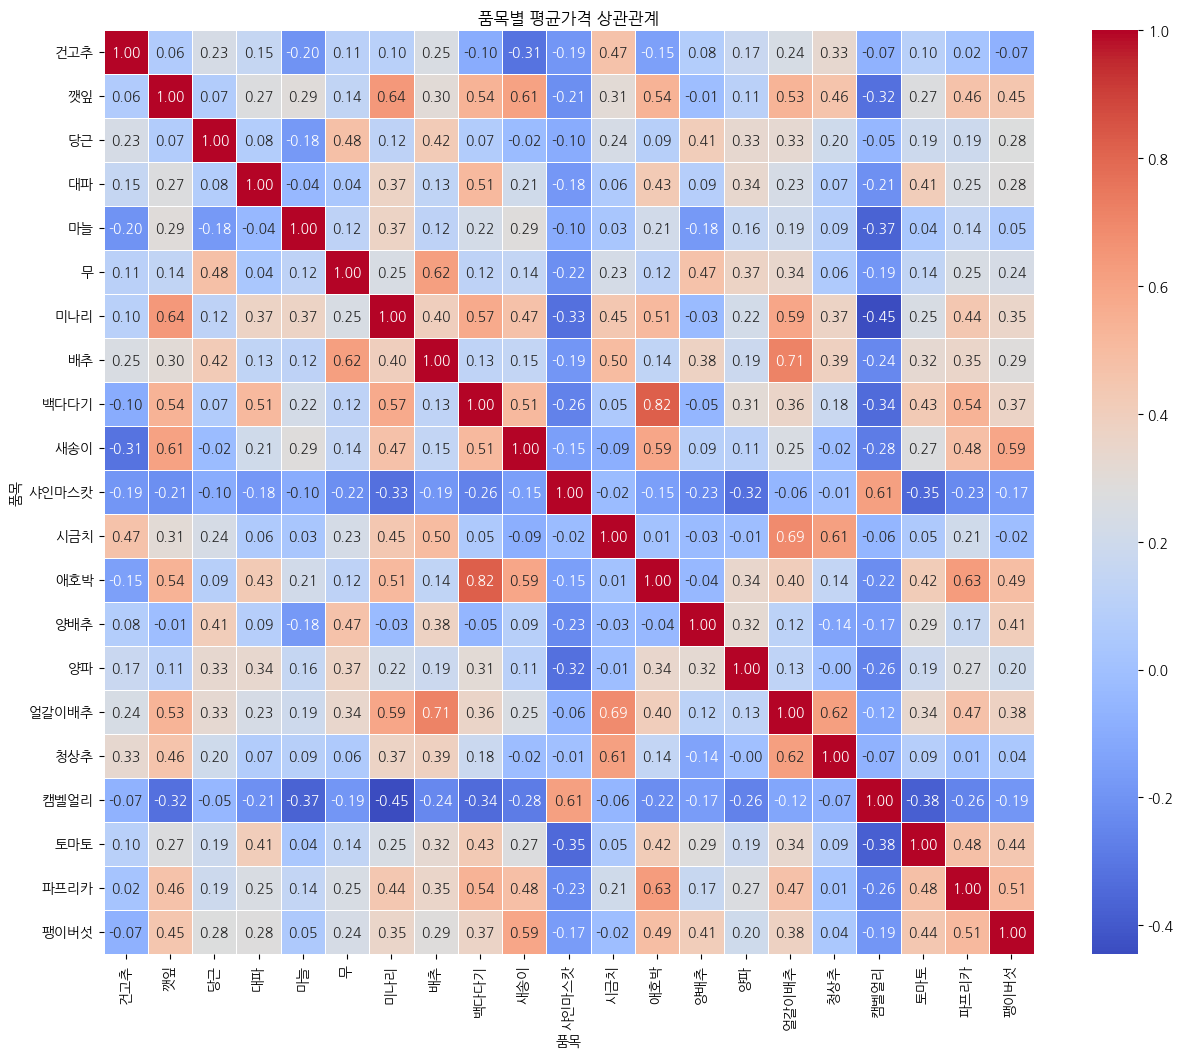

In [191]:
# 1. 데이터를 피벗 테이블로 변환 (행: 날짜, 열: 품목, 값: 평균가격)
pivot_df = train_raw.pivot(index='date', columns='품목', values='평균가격')
# 2. 상관계수 계산
corr_matrix = pivot_df.corr()
# 3. 히트맵 그리기
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('품목별 평균가격 상관관계')
plt.show()

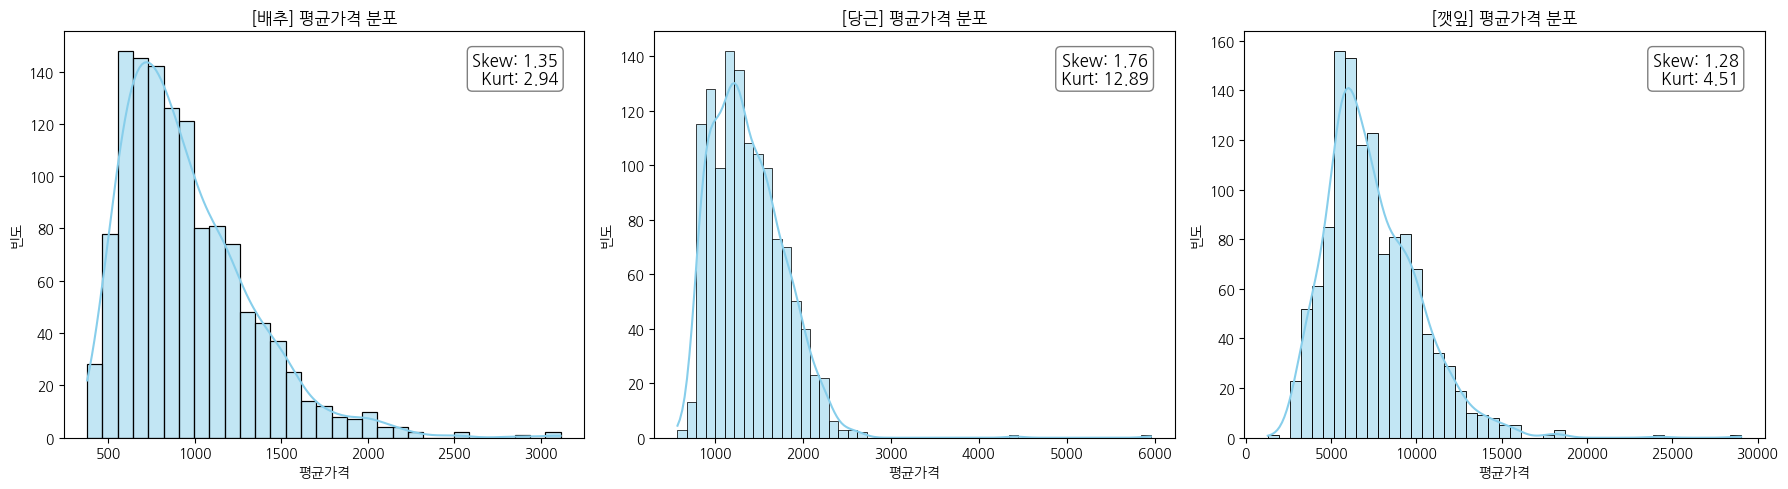

In [192]:
# '배추', '당근', '깻잎' 품목별 평균가격 분포 시각화 및 왜도/첨도 계산

items = ['배추', '당근', '깻잎']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, item in enumerate(items):
    subset = train_raw[train_raw['품목'] == item]['평균가격']
    sk, ku = skew(subset), kurtosis(subset)
    
    sns.histplot(subset, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'[{item}] 평균가격 분포')
    axes[i].set_xlabel('평균가격')
    axes[i].set_ylabel('빈도')
    
    textstr = f'Skew: {sk:.2f}\nKurt: {ku:.2f}'
    axes[i].text(0.95, 0.95, textstr, transform=axes[i].transAxes, fontsize=12,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.tight_layout()
plt.show()

## 3. 데이터 제약, 전처리 및 파생 변수 생성

In [193]:
# 병합하여 전처리 수행
combined_df = pd.concat([train_raw, test_raw], axis=0).sort_values('date').reset_index(drop=True)

crops = combined_df['품목'].unique().tolist()


In [194]:
processed_dfs = []
for crop in crops:
    temp_df = combined_df[combined_df['품목'] == crop].copy()
    temp_df = temp_df.set_index('date').asfreq('D')

    # # 1. 파생 변수: _is_season 생성
    temp_df['_is_season'] = 0
    temp_df.loc[temp_df['총거래물량'].notna(), '_is_season'] = 1
    temp_df['_is_season'] = (temp_df['총거래물량'] > 0).astype(int)
    temp_df['품목'] = crop
      
    # 2. fillna(0)는 수치형 컬럼에만 선택적으로 적용
    numeric_cols = ['총거래금액', '총거래물량']
    temp_df[numeric_cols] = temp_df[numeric_cols].fillna(0)

    # 3. ffill()은 모든 컬럼에 적용
    temp_df = temp_df.ffill()    
    
    # 4. 날짜 관련 파생 변수는 인덱스(DATE)에서 다시 생성 (정확도 보장)
    temp_df['Year'] = temp_df.index.year
    temp_df['Month'] = temp_df.index.month
    temp_df['Day'] = temp_df.index.day
    temp_df['DayOfWeek'] = temp_df.index.day_name()
    
    # 요일 순서 유지를 위해 다시 Categorical 설정 (preprocess.py와 동일한 기준)
    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    temp_df['DayOfWeek'] = pd.Categorical(temp_df['DayOfWeek'], categories=days_order, ordered=True)
    

    
    processed_dfs.append(temp_df)

combined_df = pd.concat(processed_dfs).reset_index()


In [195]:
# 타겟 변수 변환: np.log1p (저가 품목 오차율 통제)
# 원본 가격 저장을 위해 복사본 생성 (NMAE 계산용)
combined_df_orig = combined_df.copy()

combined_df['총거래금액'] = np.log1p(combined_df['총거래금액'])
combined_df['총거래물량'] = np.log1p(combined_df['총거래물량'])
combined_df['평균가격'] = np.log1p(combined_df['평균가격'])

# 명절 특성 추가
holidays = pd.to_datetime(['2022-02-01', '2022-09-10', '2023-01-22', '2023-09-29', 
                           '2024-02-10', '2024-09-17', '2025-01-29', '2025-10-06', '2026-02-17'])

# 초기값을 0이 아닌 특이값으로 설정하여 평시와 명절 당일을 구분
combined_df['holiday'] = 0
combined_df['holiday_dday'] = 999  # 평시를 의미하는 Out-of-range 값

for h in holidays:
    start = h - pd.Timedelta(days=14)
    end = h + pd.Timedelta(days=7)
    mask = (combined_df['date'] >= start) & (combined_df['date'] <= end)
    combined_df.loc[mask, 'holiday'] = 1
    # 기존 값보다 더 절댓값이 작은(명절에 더 가까운) 경우에만 업데이트 (중첩 방지)
    dday_vals = (combined_df.loc[mask, 'date'] - h).dt.days
    combined_df.loc[mask, 'holiday_dday'] = dday_vals
    
# 1. Lag 변수 생성 (품목별로 격리하여 shift)
for lag in [1, 2, 3, 7, 14]:
    combined_df[f'lag_{lag}'] = combined_df.groupby('품목')['총거래금액'].transform(lambda x: x.shift(lag))

# 2. 이동평균 및 표준편차 생성
for window in [7, 14, 28]:
    group_obj = combined_df.groupby('품목')['총거래금액']
    combined_df[f'ma_{window}'] = group_obj.transform(lambda x: x.rolling(window).mean())
    combined_df[f'std_{window}'] = group_obj.transform(lambda x: x.rolling(window).std())

combined_df = combined_df.dropna()
print("데이터 전처리 완료. shape:", combined_df.shape)


데이터 전처리 완료. shape: (31517, 25)


#### 유가 데이터 추가

In [196]:
oil = pd.read_csv('data/oil_price.csv')
# BOM 제거 및 컬럼명 정리
oil.columns = [col.strip().replace('\ufeff', '') for col in oil.columns]
oil = oil.rename(columns={'date': 'date', 'price': 'Oil_Price'})

oil['date'] = pd.to_datetime(oil['date'])
combined_df['date'] = pd.to_datetime(combined_df['date'])

combined_df = pd.merge(combined_df, oil, on='date', how='left')


In [197]:
# 4. 결측치 확인 및 처리 (유가는 주말/공휴일에 데이터가 없을 수 있음)
nan_total = combined_df['Oil_Price'].isna().sum()
if nan_total > 0:
    print(f"⚠️ 유가 결측치 발생: {nan_total}건")
    # 가장 가까운 값으로 채움
    combined_df['Oil_Price'] = combined_df['Oil_Price'].ffill().bfill()

print("✅ 유가 데이터가 'Oil_Price' 컬럼명으로 성공적으로 결합되었습니다.")
print(combined_df[['date', 'Oil_Price']].head())


⚠️ 유가 결측치 발생: 102건
✅ 유가 데이터가 'Oil_Price' 컬럼명으로 성공적으로 결합되었습니다.
        date  Oil_Price
0 2022-01-28     101.71
1 2022-01-29     101.71
2 2022-01-30     101.71
3 2022-01-31     102.42
4 2022-02-01     102.42


In [198]:
# 28일 전 유가 정보 생성 (28일 후 가격 예측 시 '미래의 알려진 정보'로 쓰임)
combined_df['Oil_Price_lag28'] = combined_df.groupby('품목')['Oil_Price'].shift(28)

# 결측치는 가까운 값으로 채움
combined_df['Oil_Price_lag28'] = combined_df['Oil_Price_lag28'].ffill().bfill()


#### 날씨 데이터 추가

In [199]:
df_weather = pd.read_csv(DATA_PATH + 'weather_data.csv') 
df_weather.columns = [col.strip().replace('\ufeff', '') for col in df_weather.columns]
df_weather


,date,avg_temp,max_temp,min_temp,precip,location
0,2021-12-01,1.3,4.4,-3.7,3.2,논산
1,2021-12-01,4.5,6.4,1.8,4.3,무안
2,2021-12-01,0.6,3.4,-2.3,1.5,상주
3,2021-12-01,6.1,7.6,4.3,7.3,신안
4,2021-12-01,8.0,9.4,7.0,8.0,제주
...,...,...,...,...,...,...
13695,2026-01-31,4.5,7.7,2.6,6.2,제주
13696,2026-01-31,-1.4,7.8,-8.6,-0.4,창녕
13697,2026-01-31,-9.2,-1.8,-16.8,-7.5,평창
13698,2026-01-31,-5.8,1.5,-12.7,-3.8,포천


In [200]:
df_weather

,date,avg_temp,max_temp,min_temp,precip,location
0,2021-12-01,1.3,4.4,-3.7,3.2,논산
1,2021-12-01,4.5,6.4,1.8,4.3,무안
2,2021-12-01,0.6,3.4,-2.3,1.5,상주
3,2021-12-01,6.1,7.6,4.3,7.3,신안
4,2021-12-01,8.0,9.4,7.0,8.0,제주
...,...,...,...,...,...,...
13695,2026-01-31,4.5,7.7,2.6,6.2,제주
13696,2026-01-31,-1.4,7.8,-8.6,-0.4,창녕
13697,2026-01-31,-9.2,-1.8,-16.8,-7.5,평창
13698,2026-01-31,-5.8,1.5,-12.7,-3.8,포천


In [201]:
def get_weather_flags(df_weather):
    df_w = df_weather.copy()
    # 이미 위에서 컬럼 정제를 했다고 가정하지만 함수 내에서도 한 번 더 처리
    df_w.columns = [col.strip().replace('\ufeff', '') for col in df_w.columns]
    df_w['date'] = pd.to_datetime(df_w['date'])
    df_w['day_of_year'] = df_w['date'].dt.dayofyear
    
    # ... (rest of the logic)
    baseline = df_w.groupby(['location', 'day_of_year'])['avg_temp'].agg(['mean', 'std']).reset_index()
    baseline.columns = ['location', 'day_of_year', 'temp_mu', 'temp_sigma']
    df_w = df_w.merge(baseline, on=['location', 'day_of_year'], how='left')

    df_w['flag_extreme_hot'] = ((df_w['avg_temp'] - df_w['temp_mu']) > 1.5 * df_w['temp_sigma']).astype(int)
    df_w['flag_extreme_cold'] = ((df_w['avg_temp'] - df_w['temp_mu']) < -1.5 * df_w['temp_sigma']).astype(int)
    
    df_w['flag_heatwave'] = (df_w['max_temp'] >= 33).astype(int)
    df_w['flag_coldwave'] = (df_w['min_temp'] <= -10).astype(int)
    df_w['flag_heavy_rain'] = (df_w['precip'] >= 80).astype(int)
    
    df_w['precip_15d'] = df_w.groupby('location')['precip'].transform(lambda x: x.rolling(15, min_periods=1).sum())
    df_w['flag_drought'] = (df_w['precip_15d'] < 5).astype(int)

    flag_cols = ['date', 'location', 'flag_extreme_hot', 'flag_extreme_cold', 
                 'flag_heatwave', 'flag_coldwave', 'flag_heavy_rain', 'flag_drought']
    return df_w[flag_cols]

df_weather_flags = get_weather_flags(df_weather)


In [202]:
# 확장된 주산지 매핑
item_region_map = {
    '배추': ['평창', '해남'],       # 고랭지(평창), 겨울(해남)
    '무': ['제주', '평창'],         # 겨울(제주/해남), 여름(평창)
    '양파': ['목포', '밀양'],               # 전국 최대 양파 주산지 2곳
    '마늘': ['밀양', '목포'],               # 한지/난지형 마늘 주산지
    '대파': ['신안', '평창'],       # 전남권 대파 벨트 (신안은 대파 핵심)
    '당근': ['제주'],                       # 국내 당근 생산의 압도적 비중
    '청상추': ['부여'],             # 논산은 상추/엽채류의 메카
    '깻잎': ['상주'],
    '시금치': ['동두천', '신안'],             # 섬초 및 겨울 시금치
    '백다다기': ['상주'],           # 오이 주산지(상주)
    '애호박': ['상주', '부여'],
    '샤인마스캇': ['상주'],                 # 포도 최대 주산지 중 하나
    '캠벨얼리': ['상주'],
    '토마토': ['평창'],
    '파프리카': ['평창'],
    '양배추': ['제주', '평창', '목포'],
    '건고추': ['해남']              # 노지 채소 산지 기반
}

all_regions = ['해남', '평창', '목포', '제주', '신안', '밀양', '상주', '동두천', '부여']

In [203]:
def merge_only_flags(df_combined, df_weather_flags):
    final_dfs = []
    flag_cols = [c for c in df_weather_flags.columns if 'flag_' in c]
    # 컬럼 불일치 방제를 위해 date 컬럼명을 통일
    df_combined['date'] = pd.to_datetime(df_combined['date'])
    
    for item in df_combined['품목'].unique():
        item_df = df_combined[df_combined['품목'] == item].copy()
        target_regions = item_region_map.get(item, all_regions)
        
        # 해당 주산지들 중 하나라도 위험 플래그가 1이면 1로 처리
        weather_summary = df_weather_flags[df_weather_flags['location'].isin(target_regions)]
        weather_summary = weather_summary.groupby('date').max().reset_index()
        
        # location 컬럼은 groupby 후 의미 없으므로 제거
        if 'location' in weather_summary.columns:
            weather_summary = weather_summary.drop(columns=['location'])
        
        merged = item_df.merge(weather_summary, on='date', how='left')
        merged[flag_cols] = merged[flag_cols].fillna(0).astype(int)

        final_dfs.append(merged)
        
    return pd.concat(final_dfs, ignore_index=True)


In [204]:
# 실행
combined_df = merge_only_flags(combined_df, df_weather_flags)
combined_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31517 entries, 0 to 31516
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               31517 non-null  datetime64[ns]
 1   품목                 31517 non-null  object        
 2   총거래금액              31517 non-null  float64       
 3   총거래물량              31517 non-null  float64       
 4   평균가격               31517 non-null  float64       
 5   Year               31517 non-null  int32         
 6   Quarter            31517 non-null  float64       
 7   Month              31517 non-null  int32         
 8   Week               31517 non-null  float64       
 9   Day                31517 non-null  int32         
 10  DayOfWeek          31517 non-null  category      
 11  _is_season         31517 non-null  int64         
 12  holiday            31517 non-null  int64         
 13  holiday_dday       31517 non-null  int64         
 14  lag_1 

In [205]:
def apply_crop_specific_lags(df_final):
    """
    품목별 생리 특성에 맞는 시차 및 누적 플래그 생성
    """
    # 1. 품목 그룹 정의
    short_cycle = ['청상추', '시금치', '깻잎', '미나리', '얼갈이배추']
    mid_cycle = ['토마토', '애호박', '파프리카', '백다다기']
    long_cycle = ['배추', '무', '양파', '마늘', '당근', '양배추', '건고추']
    
    df_lagged = df_final.sort_values(['품목', 'date']).copy()
    
    # 기본 위험 플래그 리스트
    target_flags = ['flag_heatwave', 'flag_heavy_rain', 'flag_coldwave']
    
    for item in df_lagged['품목'].unique():
        mask = df_lagged['품목'] == item
        
        if item in short_cycle:
            # 엽채류: 7일, 14일 시차 및 7일 누적합
            for flag in target_flags:
                df_lagged.loc[mask, f'{flag}_L7'] = df_lagged[mask][flag].shift(7)
                df_lagged.loc[mask, f'{flag}_R7'] = df_lagged[mask][flag].rolling(7).sum()
                
        elif item in mid_cycle:
            # 과채류: 14일, 21일 시차 및 14일 누적합
            for flag in target_flags:
                df_lagged.loc[mask, f'{flag}_L14'] = df_lagged[mask][flag].shift(14)
                df_lagged.loc[mask, f'{flag}_R14'] = df_lagged[mask][flag].rolling(14).sum()
                
        elif item in long_cycle:
            # 구근/저장: 30일 시차 및 30일 누적합
            for flag in target_flags:
                df_lagged.loc[mask, f'{flag}_L30'] = df_lagged[mask][flag].shift(30)
                df_lagged.loc[mask, f'{flag}_R30'] = df_lagged[mask][flag].rolling(30).sum()
                
    lag_cols = [c for c in df_lagged.columns if any(suffix in c for suffix in ['_L', '_R'])]
    df_lagged[lag_cols] = df_lagged[lag_cols].fillna(0)
    
    return df_lagged




In [206]:
# 실행
combined_df = apply_crop_specific_lags(combined_df)

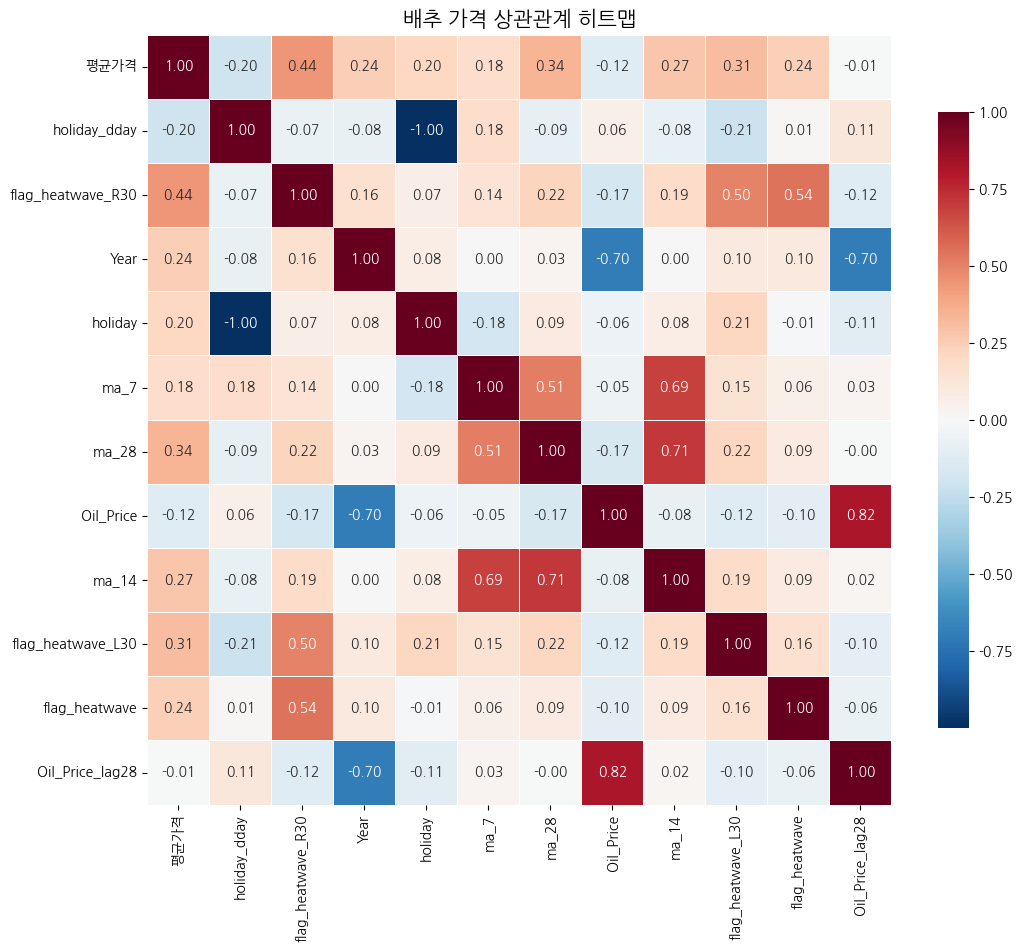

In [207]:
# 가격과 다른 변수들의 상관관계 히트맵(배추를 기준으로)
baechu_df = combined_df[combined_df['품목'] == '배추']
corr_matrix = baechu_df.corr(numeric_only=True)
mandatory_cols = ['Oil_Price', 'Oil_Price_lag28', 'holiday', 'holiday_dday']

top_10_logic = corr_matrix['평균가격'].abs().sort_values(ascending=False).index.tolist()
if '평균가격' in top_10_logic:
    top_10_logic.remove('평균가격')
top_10_cols = top_10_logic[:10]

final_cols_temp = list(set(top_10_cols + mandatory_cols))
if '평균가격' in final_cols_temp:
    final_cols_temp.remove('평균가격')

final_cols = ['평균가격'] + final_cols_temp  
final_corr = corr_matrix.loc[final_cols, final_cols]
plt.figure(figsize=(12, 10))

sns.heatmap(final_corr, 
            annot=True, 
            fmt=".2f", 
            cmap='RdBu_r',  
            center=0,       
            linewidths=0.5,
            cbar_kws={"shrink": .8})

plt.title('배추 가격 상관관계 히트맵', fontsize=15)
plt.show()

## 4. 품목 임베딩 사전 생성 (PCA)

In [208]:
# 품목별 '정체성'을 나타내는 다차원 통계량 추출
crop_stats = []
train_end_date = train_raw['date'].max()
for crop in crops:
    # 해당 품목의 로그 변환된 데이터 추출
    item_data = combined_df[(combined_df['품목'] == crop) & (combined_df['date'] <= train_end_date)]
    
    # 1) 기초 통계
    mean_log_price = item_data['평균가격'].mean()
    volatility = item_data['평균가격'].std() 
    trade_freq = item_data['_is_season'].mean()
    
    # 2) 유가 민감도 (상관계수)
    oil_corr = item_data[['평균가격', 'Oil_Price']].corr().iloc[0, 1]
    
    # 3) 기상 민감도
    heatwave_mask = item_data['flag_heatwave'] == 1
    if heatwave_mask.any():
        weather_impact = item_data[heatwave_mask]['평균가격'].mean() - mean_log_price
    else:
        weather_impact = 0 
    
    crop_stats.append([volatility, trade_freq, mean_log_price, oil_corr, weather_impact])

# 스케일링 및 PCA
scaler = StandardScaler()
crop_stats_scaled = scaler.fit_transform(np.nan_to_num(crop_stats))

pca = PCA(n_components=3)
crop_embeddings_pca = pca.fit_transform(crop_stats_scaled)

crop_vec_dict = {crop: emb for crop, emb in zip(crops, crop_embeddings_pca)}


## 5. 모델링 파트 1: ML (LGBM) - 독립 모델 학습 및 예측

In [ ]:
# Train/Test 분리 (date 컬럼 기준)
train_df = combined_df[combined_df['date'] <= train_end_date].copy()
test_df = combined_df[combined_df['date'] > train_end_date].copy()

def get_features(df_item):
    features = ['holiday', 'holiday_dday', '_is_season', 'Oil_Price','Oil_Price_lag28']
    features += ['vec0', 'vec1', 'vec2']
    
    exclude_cols = ['date', 'date', '품목', '평균가격', '총거래금액', '총거래물량']
    dynamic_features = [c for c in df_item.columns if c not in exclude_cols and c not in features]
    
    return features + dynamic_features

In [ ]:
horizons = [7, 14, 28]
lgbm_models = {}
lgbm_preds = {}

for crop in crops:
    lgbm_models[crop] = {}
    lgbm_preds[crop] = {}
    
    item_train = train_df[train_df['품목'] == crop].copy()
    item_test = test_df[test_df['품목'] == crop].copy()
    
    if len(item_train) == 0: continue
    
    vec = crop_vec_dict[crop]
    for _df in [item_train, item_test]:
        _df['vec0'], _df['vec1'], _df['vec2'] = vec[0], vec[1], vec[2]
        
    features = get_features(item_train)
    
    for h in horizons:
        y_train = item_train['평균가격'].shift(-h).dropna()
        X_train = item_train[features].loc[y_train.index]
        
        y_test = item_test['평균가격'].shift(-h).dropna()
        X_test = item_test[features].loc[y_test.index]
        
        if len(y_test) == 0: continue
        
        model = lgb.LGBMRegressor(objective='regression_l1', n_estimators=150, random_state=42, verbose=-1)
        model.fit(X_train, y_train)
        
        lgbm_models[crop][h] = model
        preds = model.predict(X_test)
        lgbm_preds[crop][h] = pd.Series(preds, index=y_test.index)

print("LGBM 학습 완료.")


LGBM 학습 완료.


## 6. 모델링 파트 2: DL (Chronos-2 Large) - Zero-shot 기반 문맥 추론

In [ ]:
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

# 1. 크로노스 전용 데이터셋 형태로 변환
df_chronos = combined_df.rename(columns={
    'date': 'timestamp', 
    '품목': 'item_id', 
    '평균가격': 'target'
})

# 2. 공변량 리스트업
covariate_cols = [c for c in df_chronos.columns if 'flag_' in c or 'holiday' in c or 'Oil_Price_lag28' in c]

# 3. TimeSeriesDataFrame 생성 
ts_data = TimeSeriesDataFrame.from_data_frame(
    df_chronos[['item_id', 'timestamp', 'target'] + covariate_cols],
    id_column="item_id",
    timestamp_column="timestamp"
)

# 3. 데이터 분할
# 과거 문맥: 데이터의 시작점부터 훈련 종료일까지
start_date = ts_data.index.get_level_values("timestamp").min() # 데이터의 첫 날짜 추출
train_end_date = pd.Timestamp(train_end_date)# 확실히 Timestamp 타입으로 변환

past_data = ts_data.slice_by_time(start_date, train_end_date + pd.Timedelta(days=1))

# 미래 공백(Covariates) 날짜 범위 설정
prediction_start = train_end_date + pd.Timedelta(days=1)
prediction_end = train_end_date + pd.Timedelta(days=29)

future_covariates_df = ts_data.slice_by_time(prediction_start, prediction_end)[covariate_cols]

In [ ]:
# 4. Predictor 설정 및 모델 로드
# 모델 사이즈를 'large'로 명확히 지정하고, 추가 학습 없이 로드합니다.
predictor = TimeSeriesPredictor(
    prediction_length=28, 
    target="target",
    eval_metric="MAE",
    known_covariates_names=covariate_cols
)

# Chronos 모델 경로를 명시적으로 지정하여 Large 모델을 불러옵니다.
predictor.fit(
    past_data,
    hyperparameters={
        "Chronos": {
            "model_path": "large",  # 'model_size' 대신 'model_path' 사용 권장
            "max_steps": 0          # 학습 없이 Zero-shot 사용
        }
    }
)

# 5. 모델 로드 완료 안내
# (실제 추론은 아래 Rolling Window 루프에서 수행됩니다)
print("✅ Chronos Large 모델 로드 및 준비 완료.")


Beginning AutoGluon training...
AutoGluon will save models to '/mnt/c/Users/ysj58/github/Time_Project/AutogluonModels/ag-20260317_155000'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.10.20
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Thu Jun  5 18:30:46 UTC 2025
CPU Count:          12
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 11.99/11.99 GB
Total GPU Memory:   Free: 11.99 GB, Allocated: 0.01 GB, Total: 11.99 GB
GPU Count:          1
Memory Avail:       7.46 GB / 15.49 GB (48.1%)
Disk Space Avail:   117.24 GB / 930.60 GB (12.6%)

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': MAE,
 'hyperparameters': {'Chronos': {'max_steps': 0, 'model_path': 'large'}},
 'known_covariates_names': ['holiday',
                            'holiday_dday',
                            'Oil_Price_lag28',
                            'flag_extreme_

✅ Chronos Large 모델 로드 및 준비 완료.


In [ ]:
# 1. 날짜 범위 설정 (28일 반복)
forecast_origin_dates = pd.date_range(start=train_end_date, periods=28, freq='D')

# 최종 결과를 담을 딕셔너리
final_rolling_lgbm_preds = {crop: {h: [] for h in horizons} for crop in crops}
final_rolling_chronos_preds = {crop: {h: [] for h in horizons} for crop in crops}

print(f"🚀 {len(forecast_origin_dates)}일간의 Rolling Window 예측 루프를 시작합니다...")

for origin_date in forecast_origin_dates:
    # --- [A] 크로노스 부분 ---
    # 과거 문맥: origin_date 당일까지 (slice_by_time은 마지막 날짜 미포값이므로 +1일)
    start_date = ts_data.index.get_level_values("timestamp").min() # 데이터의 첫 날짜 추출
    past_data_rolling = ts_data.slice_by_time(start_date, origin_date + pd.Timedelta(days=1))
    
    # 미래 정보: origin_date 다음 날부터 28일치
    p_start = origin_date + pd.Timedelta(days=1)
    p_end = p_start + pd.Timedelta(days=28)
    # covariate_cols가 ts_data 인덱스 범위를 벗어나지 않는지 확인 후 추출
    future_cov_rolling = ts_data.slice_by_time(p_start, p_end)[covariate_cols]

    # 크로노스 예측 실행
    chronos_res = predictor.predict(past_data_rolling, known_covariates=future_cov_rolling, random_seed=42)
    
    # --- [B] LGBM 부분 ---
    # origin_date 시점의 데이터 추출
    item_origin_data = combined_df[combined_df['date'] == origin_date].copy()
    
    for crop in crops:
        if crop not in lgbm_models: continue
        crop_origin_data = item_origin_data[item_origin_data['품목'] == crop].copy()
        if len(crop_origin_data) == 0: continue
            
        # PCA 벡터 주입
        vec = crop_vec_dict[crop]
        crop_origin_data['vec0'], crop_origin_data['vec1'], crop_origin_data['vec2'] = vec[0], vec[1], vec[2]
        X_origin = crop_origin_data[get_features(crop_origin_data)]

        # 각 Horizon별 예측
        for h in horizons:
            # 1. LGBM 예측
            if h in lgbm_models[crop]:
                lgbm_val = lgbm_models[crop][h].predict(X_origin)[0]
                final_rolling_lgbm_preds[crop][h].append(pd.Series([lgbm_val], index=[origin_date]))
            
            # 2. 크로노스 결과 추출
            target_date = origin_date + pd.Timedelta(days=h)
            if crop in chronos_res.index.get_level_values(0) and target_date in chronos_res.loc[crop].index:
                chronos_val = chronos_res.loc[crop].loc[target_date]['mean']
                final_rolling_chronos_preds[crop][h].append(pd.Series([chronos_val], index=[origin_date]))

    print(f"📅 {origin_date.strftime('%Y-%m-%d')} 기준 예측 완료")

# 결과를 사용하기 편하게 리스트에서 Series로 변환
for crop in crops:
    for h in horizons:
        if final_rolling_lgbm_preds[crop][h]:
            final_rolling_lgbm_preds[crop][h] = pd.concat(final_rolling_lgbm_preds[crop][h])
        if final_rolling_chronos_preds[crop][h]:
            final_rolling_chronos_preds[crop][h] = pd.concat(final_rolling_chronos_preds[crop][h])

print("✅ 모든 Rolling Window 예측이 완료되었습니다.")


Model not specified in predict, will default to the model with the best validation score: Chronos[large]


🚀 28일간의 Rolling Window 예측 루프를 시작합니다...


Model not specified in predict, will default to the model with the best validation score: Chronos[large]


📅 2025-12-31 기준 예측 완료


Model not specified in predict, will default to the model with the best validation score: Chronos[large]


...

📅 2026-01-24 기준 예측 완료


Model not specified in predict, will default to the model with the best validation score: Chronos[large]


📅 2026-01-25 기준 예측 완료


Model not specified in predict, will default to the model with the best validation score: Chronos[large]


📅 2026-01-26 기준 예측 완료
📅 2026-01-27 기준 예측 완료
✅ 모든 Rolling Window 예측이 완료되었습니다.


In [ ]:
import pickle
import os

# 결과 저장을 위한 폴더 생성
save_dir = 'checkpoints'
os.makedirs(save_dir, exist_ok=True)

# 1. LGBM 결과 저장
with open(f'{save_dir}/rolling_lgbm_preds.pkl', 'wb') as f:
    pickle.dump(final_rolling_lgbm_preds, f)

# 2. Chronos 결과 저장
with open(f'{save_dir}/rolling_chronos_preds.pkl', 'wb') as f:
    pickle.dump(final_rolling_chronos_preds, f)

print(f"✅ 모든 Rolling 예측 결과가 {save_dir}/ 경로에 자장되었습니다.")


✅ 모든 Rolling 예측 결과가 checkpoints/ 경로에 자장되었습니다.


In [ ]:
# # Zero-shot이 아닌, 한국 농산물 데이터에 살짝 적응시키기
# predictor.fit(
#     train_data=ts_data,
#     hyperparameters={
#         "Chronos": {"model_size": "large", "max_steps": 500} # 짧게 학습
#     }
# )

## 7. 모델링 파트 3: 가중치 최적화 및 메타 앙상블

In [ ]:
# import pickle

# # 파일로부터 데이터 불러오기
# with open('checkpoints/rolling_lgbm_preds.pkl', 'rb') as f:
#     final_rolling_lgbm_preds = pickle.load(f)

# with open('checkpoints/rolling_chronos_preds.pkl', 'rb') as f:
#     final_rolling_chronos_preds = pickle.load(f)

# print("✅ 저장된 예측 결과를 성공적으로 불러왔습니다.")


In [ ]:
import optuna
import numpy as np
import pandas as pd

def nmae(y_true, y_pred):
    mask = (y_true > 0) & (np.isfinite(y_true))
    if mask.sum() == 0: return 0.0
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / y_true[mask])

ensemble_weights = {}
final_preds = {}

optuna.logging.set_verbosity(optuna.logging.WARNING)

for crop in crops:
    ensemble_weights[crop] = {}
    final_preds[crop] = {}
    
    # combined_df_orig 사용 (실제 가격)
    item_test_orig = combined_df_orig[combined_df_orig['품목'] == crop].copy()
    item_test_orig['date'] = pd.to_datetime(item_test_orig['date'])
    item_test_orig = item_test_orig.set_index('date')
    
    for h in horizons:
        if h not in final_rolling_lgbm_preds.get(crop, {}) or h not in final_rolling_chronos_preds.get(crop, {}):
            continue
            
        # 1. 실제 정답값 준비
        y_true = item_test_orig['평균가격'].shift(-h).dropna()
        
        # 2. 공통 인덱스 추출
        common_idx = y_true.index.intersection(final_rolling_lgbm_preds[crop][h].index)
        common_idx = common_idx.intersection(final_rolling_chronos_preds[crop][h].index)
        if len(common_idx) == 0: continue
        
        y_true_subset = y_true.loc[common_idx]
        pred_lgb = final_rolling_lgbm_preds[crop][h].loc[common_idx]
        pred_chr = final_rolling_chronos_preds[crop][h].loc[common_idx]
        
        def objective(trial):
            w_lgb = trial.suggest_float('w_lgb', 0.0, 1.0)
            w_chr = 1.0 - w_lgb
            
            ensemble_log = w_lgb * pred_lgb + w_chr * pred_chr
            ensemble_exp = np.expm1(ensemble_log)
            
            return nmae(y_true_subset, ensemble_exp)
            
        study = optuna.create_study(direction='minimize')
        study.optimize(objective, n_trials=30)
        
        best_w_lgb = study.best_params['w_lgb']
        ensemble_weights[crop][h] = best_w_lgb
        
        best_ensemble_log = best_w_lgb * pred_lgb + (1.0 - best_w_lgb) * pred_chr
        final_preds[crop][h] = np.expm1(best_ensemble_log)

print("✅ 메타 앙상블 가중치 최적화 완료.")


✅ 메타 앙상블 가중치 최적화 완료.


## 8. 결과 시각화 및 모델 평가

In [ ]:
# 1. 테스트 정답지만 새로 로드
raw_test = pd.read_csv('data/test.csv') 
# 2. 컬럼명 정제 및 날짜 타입 변환
raw_test.columns = [col.strip().replace('\ufeff', '') for col in raw_test.columns]
raw_test = raw_test.rename(columns={'DATE': 'date'})
raw_test['date'] = pd.to_datetime(raw_test['date'])
# 3. 정답 가격 계산 (집계)
ground_truth = raw_test.groupby(['품목', 'date']).agg({
    '총거래금액': 'sum',
    '총거래물량': 'sum'
}).reset_index()
ground_truth['평균가격'] = 0.0
mask = ground_truth['총거래물량'] > 0
ground_truth.loc[mask, '평균가격'] = ground_truth.loc[mask, '총거래금액'] / ground_truth.loc[mask, '총거래물량']
# 4. 조회 효율을 위해 인덱스화
ground_truth = ground_truth.set_index(['품목', 'date'])
print("✅ 1월 테스트 정답지 로드 완료 및 원본 가격 산출 성공.")

✅ 1월 테스트 정답지 로드 완료 및 원본 가격 산출 성공.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def plot_final_results(crop, horizon):
    """
    특정 품목과 시점의 예측 결과를 시각화
    """
    if horizon not in final_preds.get(crop, {}):
        print(f"데이터 부족: {crop} - {horizon}일")
        return
        
    # 1. 시각화 데이터 준비
    item_test = test_df[test_df['품목'] == crop]
    y_true = np.expm1(item_test['평균가격'].shift(-horizon)).dropna()
    y_final = final_preds[crop][horizon]
    
    # 공통 기간 추출
    common_idx = y_true.index.intersection(y_final.index)
    if len(common_idx) == 0: return
    
    # 2. 그래프 그리기
    plt.figure(figsize=(12, 5))
    plt.plot(common_idx, y_true.loc[common_idx], label='Actual Price', color='black', linewidth=2, alpha=0.6)
    plt.plot(common_idx, y_final.loc[common_idx], label=f'Ensemble Pred (t+{horizon})', color='red', linestyle='--')
    
    # 가중치 정보 표시
    w_lgb = ensemble_weights[crop][horizon]
    plt.title(f"[{crop}] {horizon} Days Forecast - (LGBM Ratio: {w_lgb:.2f})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()




In [ ]:
import pandas as pd
import numpy as np

# 1. nmae 함수 재선언 (안정성 강화)
def robust_nmae(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    # 0보다 크고 유한한 값만 필터링
    mask = (y_true > 0) & (np.isfinite(y_true))
    if mask.sum() == 0:
        return np.nan
        
    # 예측값에 nan이 있는지 확인 (있으면 해당 행 제외)
    valid_mask = mask & np.isfinite(y_pred)
    if valid_mask.sum() == 0:
        return np.nan
        
    return np.mean(np.abs(y_true[valid_mask] - y_pred[valid_mask]) / y_true[valid_mask])

In [ ]:
# 2. 성적 계산 루프
total_nmaes = []

for crop in crops:
    crop_results = []
    
    for h in horizons:
        if h in final_preds.get(crop, {}):
            # 대상 및 예측 시점 설정
            forecast_origins = final_preds[crop][h].index
            target_dates = forecast_origins + pd.Timedelta(days=h)
            
            # 정답지 대조
            lookup_keys = [(crop, d) for d in target_dates]
            
            # 정답지와 매칭되는 데이터만 추출
            available_keys = [k for k in lookup_keys if k in ground_truth.index]
            
            if len(available_keys) > 0:
                y_actual = ground_truth.loc[available_keys, '평균가격'].values
                # 해당 정답 날짜에 대응하는 예측 원점(origin) 찾기
                valid_origins = [d - pd.Timedelta(days=h) for _, d in available_keys]
                y_pred = final_preds[crop][h].loc[valid_origins].values
                
                score = robust_nmae(y_actual, y_pred)
                if not np.isnan(score):
                    crop_results.append(score)
    
    if crop_results:
        avg_crop_score = np.mean(crop_results)
        print(f"📊 [{crop}] NMAE: {avg_crop_score:.4f} (데이터 {len(crop_results)*28}건 샘플)")
        total_nmaes.append(avg_crop_score)


📊 [토마토] NMAE: 0.1123 (데이터 84건 샘플)
📊 [건고추] NMAE: 0.1525 (데이터 84건 샘플)
📊 [청상추] NMAE: 0.1602 (데이터 84건 샘플)
📊 [백다다기] NMAE: 0.1012 (데이터 84건 샘플)
📊 [얼갈이배추] NMAE: 0.0978 (데이터 84건 샘플)
📊 [마늘] NMAE: 0.0475 (데이터 84건 샘플)
📊 [깻잎] NMAE: 0.1877 (데이터 84건 샘플)
📊 [양배추] NMAE: 0.1343 (데이터 84건 샘플)
📊 [당근] NMAE: 0.0572 (데이터 84건 샘플)
📊 [애호박] NMAE: 0.0956 (데이터 84건 샘플)
📊 [양파] NMAE: 0.0501 (데이터 84건 샘플)
📊 [미나리] NMAE: 0.1247 (데이터 84건 샘플)
📊 [샤인마스캇] NMAE: 0.1120 (데이터 84건 샘플)
📊 [대파] NMAE: 0.1116 (데이터 84건 샘플)
📊 [시금치] NMAE: 0.0845 (데이터 84건 샘플)
📊 [팽이버섯] NMAE: 0.1416 (데이터 84건 샘플)
📊 [파프리카] NMAE: 0.1708 (데이터 84건 샘플)
📊 [새송이] NMAE: 0.1160 (데이터 84건 샘플)
📊 [배추] NMAE: 0.0989 (데이터 84건 샘플)
📊 [무] NMAE: 0.1329 (데이터 84건 샘플)
📊 [캠벨얼리] NMAE: 1.0790 (데이터 84건 샘플)


In [ ]:

# 3. 최종 결과 출력
if total_nmaes:
    print(f"\n🏆 최종 전체 품목 평균 NMAE: {np.mean(total_nmaes):.4f}")
else:
    print("\n❌ 결과를 계산할 수 없습니다. final_preds에 유효한 값이 있는지 확인해 주세요.")
    # 디버깅: 데이터 샘플 출력
    sample_crop = crops[0]
    if sample_crop in final_preds:
        print(f"DEBUG: {sample_crop} 예측값 샘플:\n", final_preds[sample_crop][7].head())



🏆 최종 전체 품목 평균 NMAE: 0.1604


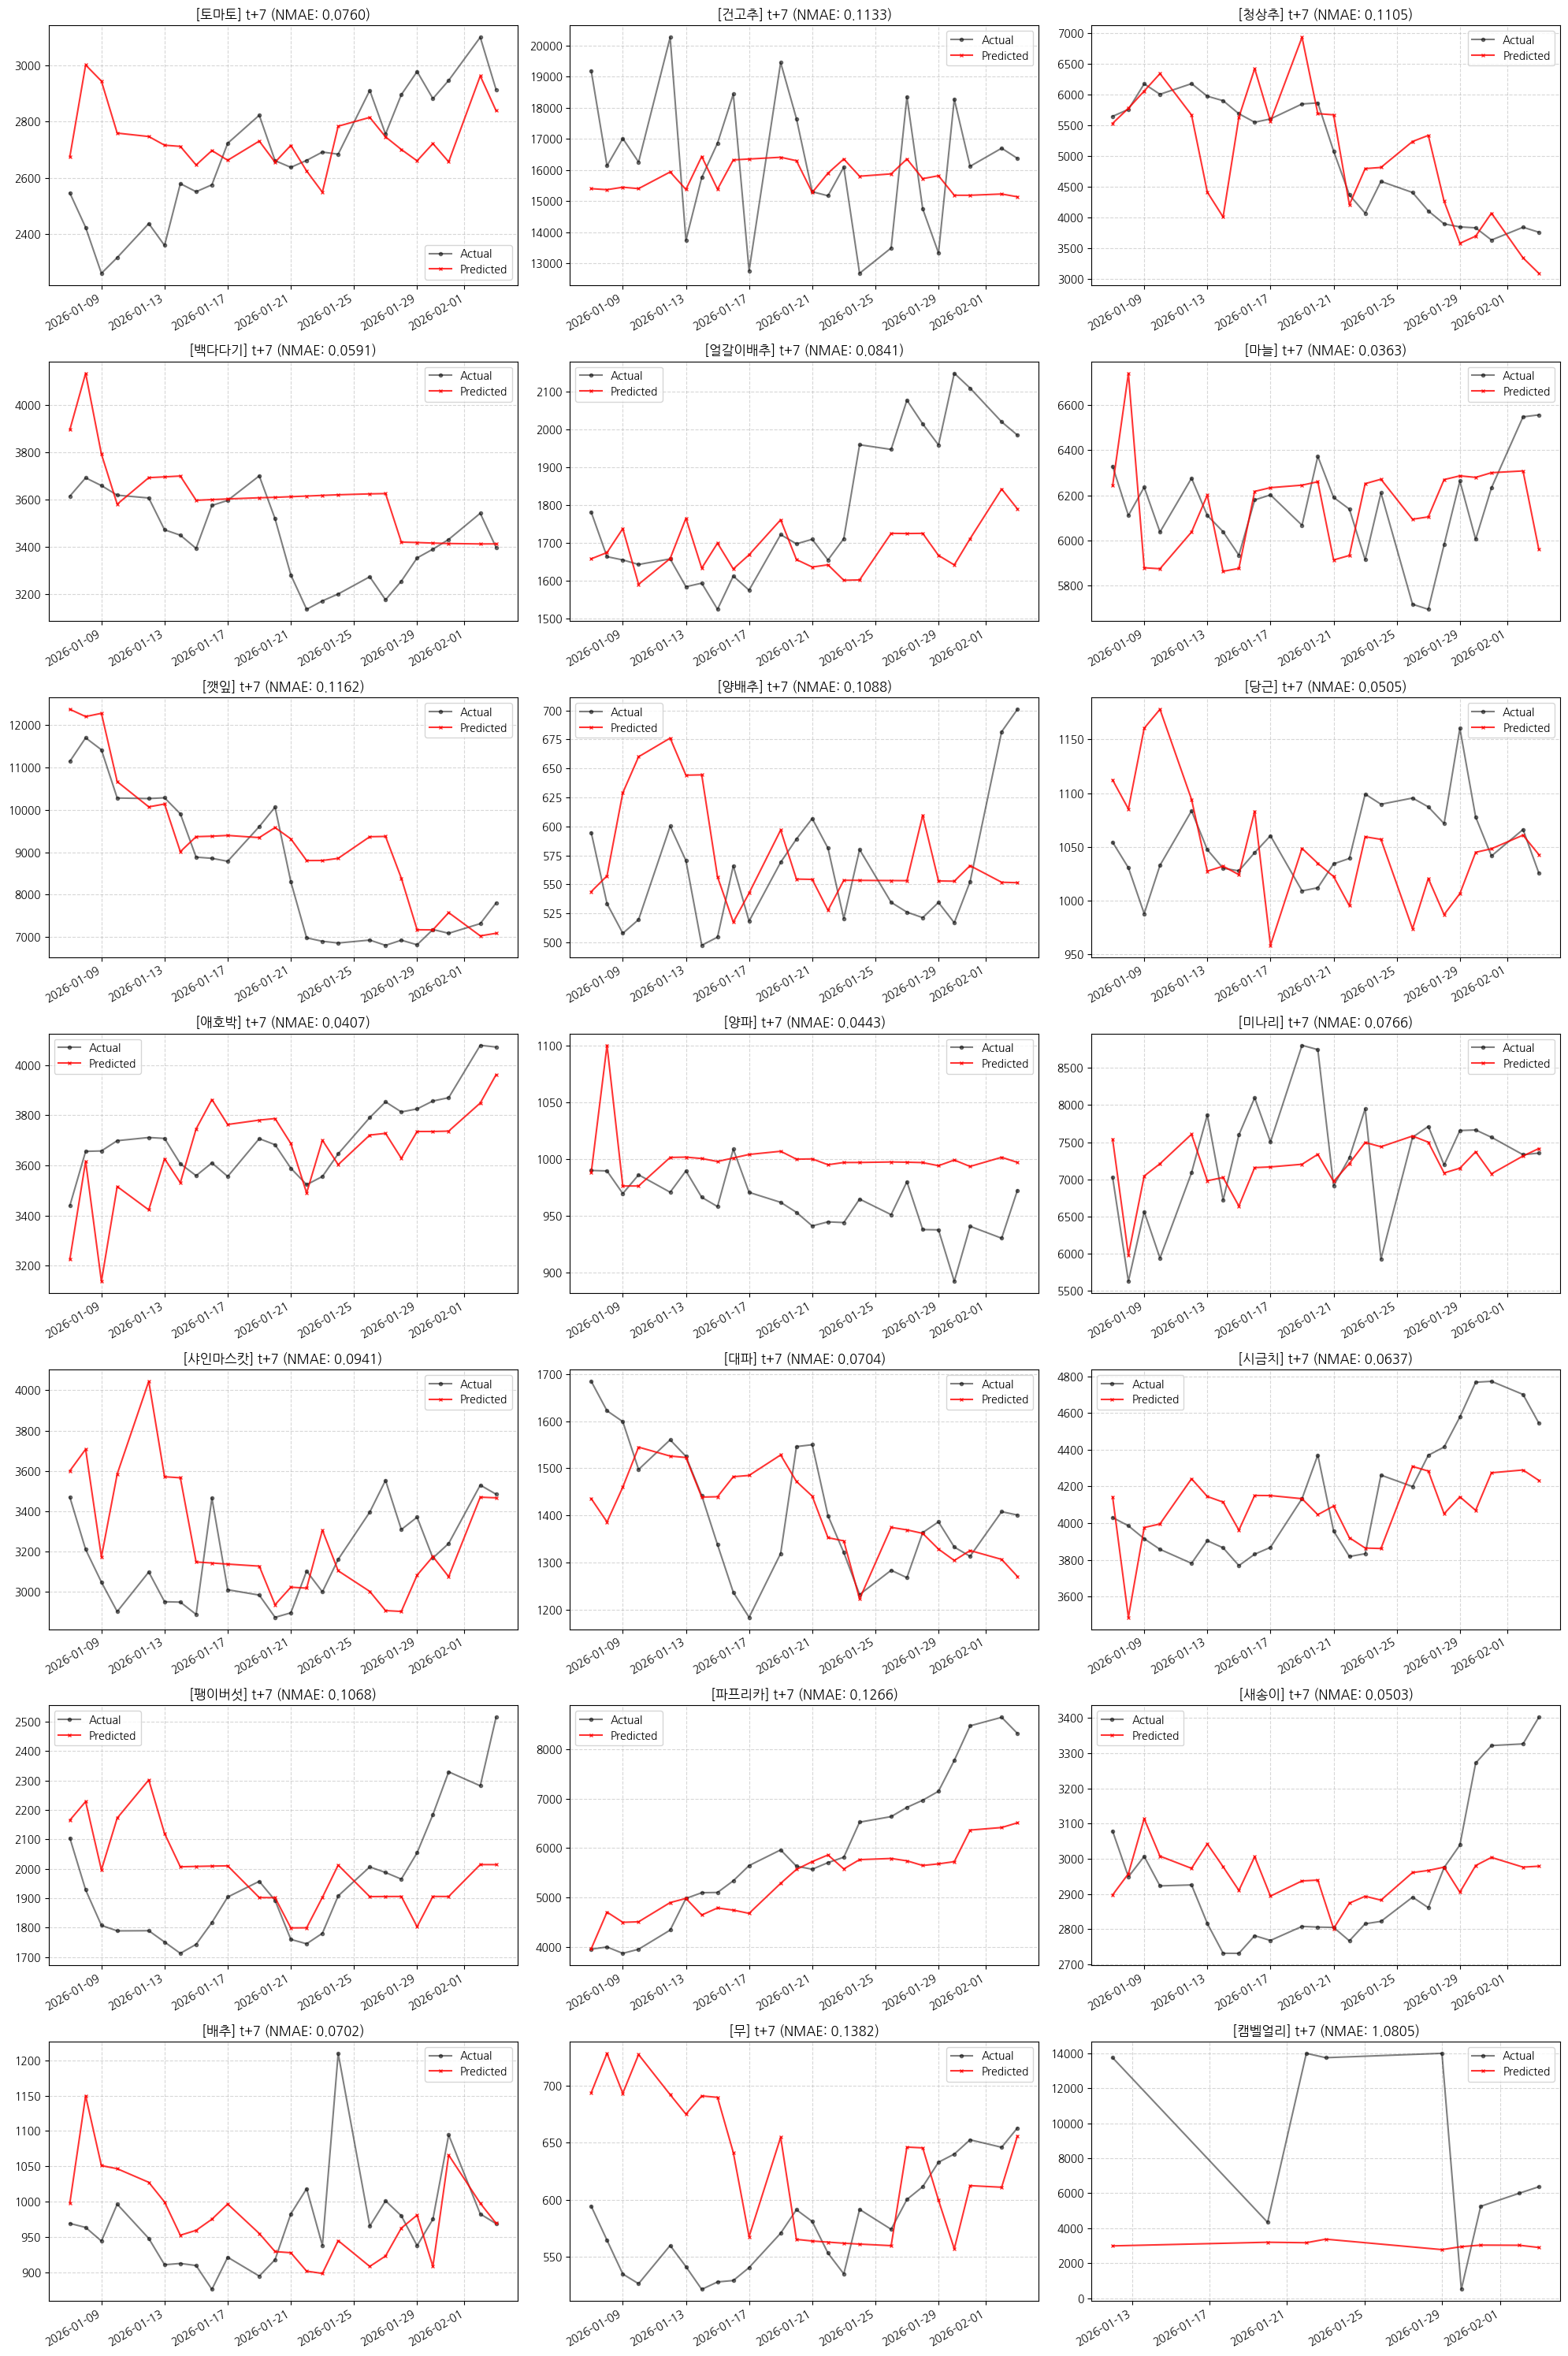

✅ 시각화된 t+7 시점 전체 평균 NMAE: 0.1294


In [ ]:
fig, axes = plt.subplots(7, 3, figsize=(20, 30))
axes = axes.flatten()
total_nmae_list = []

# 예측 기간(h=7) 설정
h = 7

for idx, crop in enumerate(crops):
    ax = axes[idx]
    
    if h in final_preds.get(crop, {}):
        # 1. 예측값 및 해당 시점(t+h)의 실제 날짜들
        origins = final_preds[crop][h].index
        target_dates = origins + pd.Timedelta(days=h)
        
        # 2. 정답지(ground_truth)에서 실제값 추출
        # (앞서 만든 ground_truth 딕셔너리 사용)
        available_keys = [k for k in [(crop, d) for d in target_dates] if k in ground_truth.index]
        if not available_keys: continue
            
        y_actual = ground_truth.loc[available_keys, '평균가격'].values
        # 실제 값에 대응하는 예측 시점(origin)의 예측값들만 추출
        valid_origins = [d - pd.Timedelta(days=h) for _, d in available_keys]
        y_pred = final_preds[crop][h].loc[valid_origins].values
        
        # 3. NMAE 계산 (지수 변환된 예측값 기준)
        # 만약 final_preds가 이미 expm1 상태라면 그대로 쓰고, 아니면 np.expm1 적용
        y_pred_raw = y_pred # (이미 앙상블 단계에서 expm1을 거쳤다고 가정)
        crop_nmae = robust_nmae(y_actual, y_pred_raw)
        total_nmae_list.append(crop_nmae)
        
        # 4. 시각화 (X축을 실제 가격 발생 날짜인 target_dates로 설정)
        actual_plot_dates = [d for _, d in available_keys]
        
        ax.plot(actual_plot_dates, y_actual, label='Actual', color='black', marker='o', markersize=3, alpha=0.5)
        ax.plot(actual_plot_dates, y_pred_raw, label='Predicted', color='red', marker='x', markersize=3, alpha=0.8)
        
        ax.set_title(f'[{crop}] t+{h} (NMAE: {crop_nmae:.4f})', fontweight='bold')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.5)
        
        # X축 날짜 가독성 개선
        plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

if total_nmae_list:
    print(f"✅ 시각화된 t+{h} 시점 전체 평균 NMAE: {np.mean(total_nmae_list):.4f}")


## 9. 최종 제출 파일 생성 (1월 1일~31일, 93행 생성)

In [ ]:
# 1. 1월 한 달간의 날짜 범위 설정 (2026년 1월 기준)
# test_df['date']가 2026년 데이터를 포함하고 있다고 가정합니다.
submit_year = test_df['date'].dt.year.iloc[0]
prediction_dates = pd.date_range(f'{submit_year}-01-01', f'{submit_year}-01-31')

submission_rows = []

print(f"📄 {submit_year}년 1월분 제출 파일 생성을 시작합니다...")

for d in prediction_dates:
    for h in [7, 14, 28]:
        # 'date'는 예측 시점(t), 'horizon'은 며칠 뒤(h)를 의미함
        row = {'date': d.strftime('%Y%m%d'), 'horizon': f't+{h}'}
        
        for crop in crops:
            # final_preds의 인덱스는 '예측을 수행한 날짜(d)'입니다.
            if crop in final_preds and h in final_preds[crop]:
                if d in final_preds[crop][h].index:
                    pred_val = final_preds[crop][h].loc[d]
                    # 혹시 nan이 저장되어 있다면 0으로 보정
                    row[f'{crop}_가격(원/kg)'] = pred_val if pd.notna(pred_val) else 0
                else:
                    # Rolling 루프 범위 밖의 날짜인 경우 (예: 1월 말)
                    row[f'{crop}_가격(원/kg)'] = 0
            else:
                row[f'{crop}_가격(원/kg)'] = 0
                
        submission_rows.append(row)

# 2. 데이터프레임 변환 및 저장
submission_df = pd.DataFrame(submission_rows)

# 3. 대회 요구 포맷에 맞춰 날짜 형식 등 확인 (필요시 수정)
# 예: 날짜 형식이 20260101 인지, 2026-01-01 인지 대회 요강에 따라 조정 가능
submission_df.to_csv('submission_weather_oil.csv', index=False, encoding='utf-8-sig')

print(f"✅ 제출 파일 생성 완료: 'submission_weather_oil.csv'")
print(f"📊 총 생성된 행 수: {len(submission_df)} (날짜 31일 x Horizon 3개 = 93행)")

# 생성된 결과 상위 5개 미리보기
display(submission_df.head())


📄 2026년 1월분 제출 파일 생성을 시작합니다...
✅ 제출 파일 생성 완료: 'submission_weather_oil.csv'
📊 총 생성된 행 수: 93 (날짜 31일 x Horizon 3개 = 93행)


,date,horizon,토마토_가격(원/kg),건고추_가격(원/kg),청상추_가격(원/kg),백다다기_가격(원/kg),얼갈이배추_가격(원/kg),마늘_가격(원/kg),깻잎_가격(원/kg),양배추_가격(원/kg),...,미나리_가격(원/kg),샤인마스캇_가격(원/kg),대파_가격(원/kg),시금치_가격(원/kg),팽이버섯_가격(원/kg),파프리카_가격(원/kg),새송이_가격(원/kg),배추_가격(원/kg),무_가격(원/kg),캠벨얼리_가격(원/kg)
0,20260101,t+7,3001.931445,15373.318382,5774.240547,4133.264049,1673.911638,6741.957757,12196.709812,557.341154,...,5982.616133,3707.364388,1386.433332,3486.185303,2228.895177,4709.810906,2957.802046,1149.856275,728.321431,2393.629196
1,20260101,t+14,3128.567200,15108.030652,4851.590542,4015.801240,1618.783233,6170.768517,9222.743980,570.811498,...,6003.031768,4116.278923,1234.464180,3416.346698,1907.257485,5521.341463,3243.153212,1135.844880,728.407732,2568.212052
2,20260101,t+28,3234.295078,13489.830662,3586.317042,3514.227997,1817.999884,6185.382761,9894.352625,571.795848,...,6165.029318,3960.017083,1341.037404,4495.591692,2413.279181,6744.296418,3199.240155,988.217375,681.444423,3405.563341
3,20260102,t+7,2944.372450,15452.155843,6054.675060,3792.392657,1737.165276,5878.251206,12273.040993,628.967757,...,7045.492146,3173.665365,1460.315923,3975.718835,1996.606651,4503.750908,3114.349343,1050.983677,693.346544,2187.576732
4,20260102,t+14,2807.000092,14767.476471,4540.900630,4019.526198,1564.410236,5826.558753,9365.933431,584.636266,...,7288.666064,3378.888936,1257.036233,3468.031742,1821.071390,5568.400210,3410.586731,1027.095174,710.461552,2269.188411
